# Rent Price Explainer

## "Your untested assumptions are the weak part, not the linear model."

**Standalone notebook.** It generates its own data and defines every function it
uses. No install, no imports from the project package, nothing written to disk.

### The usual story

You fit a regression on rental listings. R² comes back at 0.77. Someone says
*"only 0.77, let's try gradient boosting"*, and the linear model is quietly
retired. This notebook shows what that skips.

### Why this dataset is unusual

We **generate** the market, so we know the true coefficients. Real listing data
can tell you which model *predicts* better. Only a generated market can tell you
which model **recovered the truth**. Those are different questions that
people routinely conflate.

The answer key lives in `TRUE_BETAS`. Nothing that fits a model is allowed to
look at it; it is used only to score the results at the end.

### Before you run

```bash
pip install pandas numpy scikit-learn statsmodels shap matplotlib jupyter
```

About 2 minutes top to bottom, 6 charts. Nothing touches your filesystem.

### Contents

| # | Section | What you get |
|---|---|---|
| 1 | [The market and the answer key](#s1) | a generated book whose true coefficients we know |
| 2 | [The regression most people write](#s2) | levels, every column, R2 = 0.77 |
| 3 | [The four plots that decide everything](#s3) | the violations, visible before any test |
| 4 | [Why R-squared cannot be optimised](#s4) | it rises on pure noise |
| 5 | [Fixing what the diagnostics named](#s5) | error nearly halved, same model family |
| 6 | [The gradient boosting challenger](#s6) | the same data with no specification work |
| 7 | [SHAP, and the identity behind it](#s7) | coefficients and tree attributions reconciled |
| 8 | [Telling the model what the tree found](#s8) | the interaction, and recovery vs the truth |
| 9 | [What to take away](#s9) | seven findings and the honest limitation |

Every code cell opens with a header saying what it consumes and what it leaves
behind, so you can start reading at any section.

In [1]:
# ============================================================================
# 0.1  Imports and global settings
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : numpy/pandas/statsmodels/sklearn namespaces, SEED
# Note : SEED is fixed so every number in this notebook is reproducible.
# ============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42
pd.set_option("display.width", 165, "display.max_columns", 30)
print("ready")

ready


In [2]:
# ============================================================================
# 0.2  Chart styling
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : BLUE/ORANGE/AQUA palette and the style() helper
# Note : One validated palette for the whole notebook; the first three slots
#        are colourblind-safe on every pair.
# ============================================================================
# Validated categorical slots; first three are colourblind-safe on all pairs.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#b8b7b2"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "600", "axes.titlelocation": "left", "axes.titlepad": 12,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "axes.labelsize": 10,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "legend.frameon": False,
    "legend.fontsize": 9, "lines.linewidth": 2, "lines.markersize": 7,
    "figure.dpi": 110, "font.size": 10,
})


def style(ax, title=None, sub=None, xlabel=None, ylabel=None, grid="y"):
    if title:
        ax.set_title(title, pad=22 if sub else 12)
    if sub:
        ax.text(0, 1.04, sub, transform=ax.transAxes, fontsize=9.5,
                color=INK2, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    if grid:
        ax.grid(axis=grid, alpha=0.9, zorder=0)
        ax.set_axisbelow(True)
    return ax


print("palette locked")

palette locked


---
<a id="s1"></a>
## 1. The market, and the answer key

Five violations are built in deliberately, one for each thing the diagnostics
will later have to catch:

| # | violation | what it breaks |
|---|---|---|
| 1 | rent is **log**-linear in the drivers | a level-on-level fit is mis-specified |
| 2 | **heteroscedasticity**, spread grows with size | every standard error and p-value |
| 3 | **multicollinearity**, `carpet_area` ≈ 0.8 × `builtup_area` | the coefficients, not the predictions |
| 4 | **non-linearity**, age has a U-shape | any straight line through it |
| 5 | **influential points**, a penthouse cluster | the fit, via a handful of rows |

Plus a sixth that matters later: the metro-distance penalty is **steeper in
premium localities**. A main-effects linear model is blind to that unless told.
A tree finds it unaided, and that asymmetry turns out to be the real difference
between the two families.

In [3]:
# ============================================================================
# 1.1  Generate the market, and write down the answer key
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : TRUE_BETAS, generate(), df, train, test
# Note : TRUE_BETAS is the ground truth. Nothing that fits a model may read
#        it; it is used only to score recovery in section 8.
# ============================================================================
TRUE_BETAS = {
    "intercept": 5.65,
    "log_builtup_area": 0.62,      # +10% area -> ~+6.2% rent
    "bedrooms": 0.045, "bathrooms": 0.035, "floor": 0.004,
    "has_lift": 0.055, "has_parking": 0.070,
    "furnished_semi": 0.090, "furnished_full": 0.185,
    "metro_km": -0.048,            # each km from a metro costs ~4.7%
    "school_rating": 0.028, "crime_index": -0.031,
    "metro_km_x_premium": -0.038,  # the interaction OLS must be TOLD about
}
AGE_QUAD, AGE_MIN = 0.00022, 28.0
LOCALITY_EFFECT = {"riverside": 0.155, "old_town": 0.045, "tech_park": 0.190,
                   "airport_rd": -0.030, "university": 0.075,
                   "industrial": -0.115, "hill_view": 0.120}
PREMIUM = {"tech_park", "riverside"}


def generate(n=6000, seed=SEED, junk=8):
    rng = np.random.default_rng(seed)
    builtup = np.clip(np.round(np.exp(rng.normal(6.95, 0.42, n))), 280, 6500)

    # (5) influential points -- sized up FIRST so every derived column follows
    lux = rng.random(n) < 0.012
    builtup[lux] = np.round(builtup[lux] * rng.uniform(1.8, 3.1, lux.sum()))

    # (3) multicollinearity: carpet is ~deterministic in builtup
    carpet = builtup * rng.normal(0.80, 0.018, n)

    bedrooms = np.clip(np.round(builtup / 520 + rng.normal(0, .45, n)), 1, 6)
    bathrooms = np.clip(np.round(bedrooms * .75 + rng.normal(0, .35, n)), 1, 5)
    floor = rng.integers(0, 22, n)
    has_lift = ((floor > 3) | (rng.random(n) < .45)).astype(int)
    has_parking = (rng.random(n) < .62).astype(int)
    furnishing = rng.choice(["unfurnished", "semi", "full"], n, p=[.42, .38, .20])
    locality = rng.choice(list(LOCALITY_EFFECT), n,
                          p=[.15, .13, .20, .12, .15, .11, .14])
    metro_km = np.round(np.clip(rng.gamma(2.2, 1.35, n), .1, 14.), 2)
    school = np.clip(np.round(rng.normal(6.4, 1.6, n), 1), 1, 10)
    crime = np.clip(np.round(rng.normal(4.8, 1.9, n), 1), .5, 10)
    age = np.clip(np.round(rng.gamma(2.6, 6.0, n)), 0, 85)     # (4) U-shape

    b = TRUE_BETAS
    log_rent = (b["intercept"]
                + b["log_builtup_area"] * np.log(builtup)      # (1) log-linear
                + b["bedrooms"] * bedrooms + b["bathrooms"] * bathrooms
                + b["floor"] * floor + b["has_lift"] * has_lift
                + b["has_parking"] * has_parking
                + b["furnished_semi"] * (furnishing == "semi")
                + b["furnished_full"] * (furnishing == "full")
                + b["metro_km"] * metro_km + b["school_rating"] * school
                + b["crime_index"] * crime
                + AGE_QUAD * (age - AGE_MIN) ** 2
                + np.array([LOCALITY_EFFECT[x] for x in locality])
                + b["metro_km_x_premium"] * metro_km
                * np.array([x in PREMIUM for x in locality], float))

    # (2) heteroscedasticity: noise grows with size
    sigma = np.clip(.055 + .085 * (np.log(builtup) - np.log(builtup).mean()), .03, None)
    log_rent = log_rent + rng.normal(0, sigma)
    log_rent[lux] += rng.normal(.75, .20, int(lux.sum()))

    df = pd.DataFrame({
        "builtup_area": builtup.astype(float), "carpet_area": np.round(carpet, 1),
        "bedrooms": bedrooms.astype(int), "bathrooms": bathrooms.astype(int),
        "floor": floor.astype(int), "age_years": age.astype(int),
        "has_lift": has_lift, "has_parking": has_parking,
        "furnishing": furnishing, "locality": locality, "metro_km": metro_km,
        "school_rating": school, "crime_index": crime,
        "monthly_rent": np.round(np.exp(log_rent), -1)})
    for j in range(junk):
        df[f"junk_{j+1}"] = np.round(rng.normal(0, 1, n), 4)   # pure noise
    return df


df = generate()
train, test = train_test_split(df, test_size=0.25, random_state=SEED)
print(f"{len(df):,} listings | median rent {df.monthly_rent.median():,.0f}")
print(f"carpet~builtup correlation: {df.carpet_area.corr(df.builtup_area):.4f}"
      "   <- the planted collinearity")
df.head(3)

6,000 listings | median rent 29,670
carpet~builtup correlation: 0.9986   <- the planted collinearity


,builtup_area,carpet_area,bedrooms,bathrooms,floor,age_years,has_lift,has_parking,furnishing,locality,metro_km,school_rating,crime_index,monthly_rent,junk_1,junk_2,junk_3,junk_4,junk_5,junk_6,junk_7,junk_8
0,1186.0,967.4,3,2,3,12,0,1,semi,tech_park,5.93,7.2,3.2,31590.0,0.7876,0.7203,-0.7466,-0.2175,1.2943,0.9064,1.0009,0.8058
1,674.0,541.6,1,1,9,10,1,0,semi,university,3.31,6.4,2.7,22040.0,-0.1243,-2.1513,-0.6851,-0.2224,1.5695,0.3544,0.3157,-0.3058
2,1430.0,1184.2,4,3,2,20,0,1,unfurnished,hill_view,3.27,3.6,6.2,34710.0,-1.2335,0.7349,-0.7975,-0.3435,-0.7382,0.1019,0.4555,1.0585


---
<a id="s2"></a>
## 2. The regression most people actually write

Every column, rent in levels, default standard errors. This is not a straw man;
it is what a first pass looks like when nobody has asked what OLS assumes.

In [4]:
# ============================================================================
# 2.1  Fit the regression most people actually write
# ----------------------------------------------------------------------------
# In   : train
# Out  : design(), fit_ols(), predict_ols(), naive model + R2
# Note : Rent in levels, every column, non-robust errors. Not a straw man:
#        it is what a first pass looks like before anyone asks what OLS
#        assumes.
# ============================================================================
TARGET = "monthly_rent"
CATEGORICAL = ["furnishing", "locality"]
# Reference levels chosen EXPLICITLY. pandas' drop_first drops whichever level
# sorts first alphabetically -- which would silently make "full" the furnishing
# baseline and report every furnishing effect relative to the priciest level.
REFERENCE = {"furnishing": "unfurnished", "locality": "old_town"}


def design(df, log_area=True, drop_twin=True, age_curve=True,
           interaction=False, junk=False):
    X = df.drop(columns=[TARGET]).copy()
    if not junk:
        X = X.drop(columns=[c for c in X.columns if c.startswith("junk_")])
    if drop_twin:
        X = X.drop(columns=["carpet_area"], errors="ignore")
    if log_area:
        for c in ("builtup_area", "carpet_area"):
            if c in X:
                X[f"log_{c}"] = np.log(X[c]); X = X.drop(columns=[c])
    if age_curve and "age_years" in X:
        X["age_centred_sq"] = (X["age_years"] - X["age_years"].mean()) ** 2
    if interaction and {"metro_km", "locality"} <= set(X.columns):
        X["metro_km_x_premium"] = X["metro_km"] * X["locality"].isin(PREMIUM).astype(float)
    cats = [c for c in CATEGORICAL if c in X.columns]
    X = pd.get_dummies(X, columns=cats, drop_first=False, dtype=float)
    return X.drop(columns=[f"{c}_{REFERENCE[c]}" for c in cats
                           if f"{c}_{REFERENCE[c]}" in X.columns]).astype(float)


def fit_ols(df, log_y=False, cov="nonrobust", **kw):
    X = design(df, **kw)
    y = np.log(df[TARGET]) if log_y else df[TARGET]
    return sm.OLS(y.astype(float), sm.add_constant(X, has_constant="add")).fit(cov_type=cov), list(X.columns)


def predict_ols(res, cols, df, log_y=False, **kw):
    X = design(df, **kw).reindex(columns=cols, fill_value=0.0)
    p = res.predict(sm.add_constant(X, has_constant="add"))
    if not log_y:
        return np.asarray(p, float)
    # exp() alone under-predicts the mean of a log model; Duan's smearing fixes it
    return np.asarray(np.exp(p), float) * float(np.mean(np.exp(res.resid)))


naive_kw = dict(log_area=False, drop_twin=False, age_curve=False, junk=True)
naive, naive_cols = fit_ols(train, log_y=False, **naive_kw)
print(f"naive OLS   R2 = {naive.rsquared:.4f}   adj R2 = {naive.rsquared_adj:.4f}")
print("\nlooks respectable. Now ask whether it is allowed to be believed.")

naive OLS   R2 = 0.7497   adj R2 = 0.7482

looks respectable. Now ask whether it is allowed to be believed.


---
<a id="s3"></a>
## 3. The four plots that decide everything

Not tests yet, just look. Nearly every violation shows up to the eye before it
shows up in a p-value.

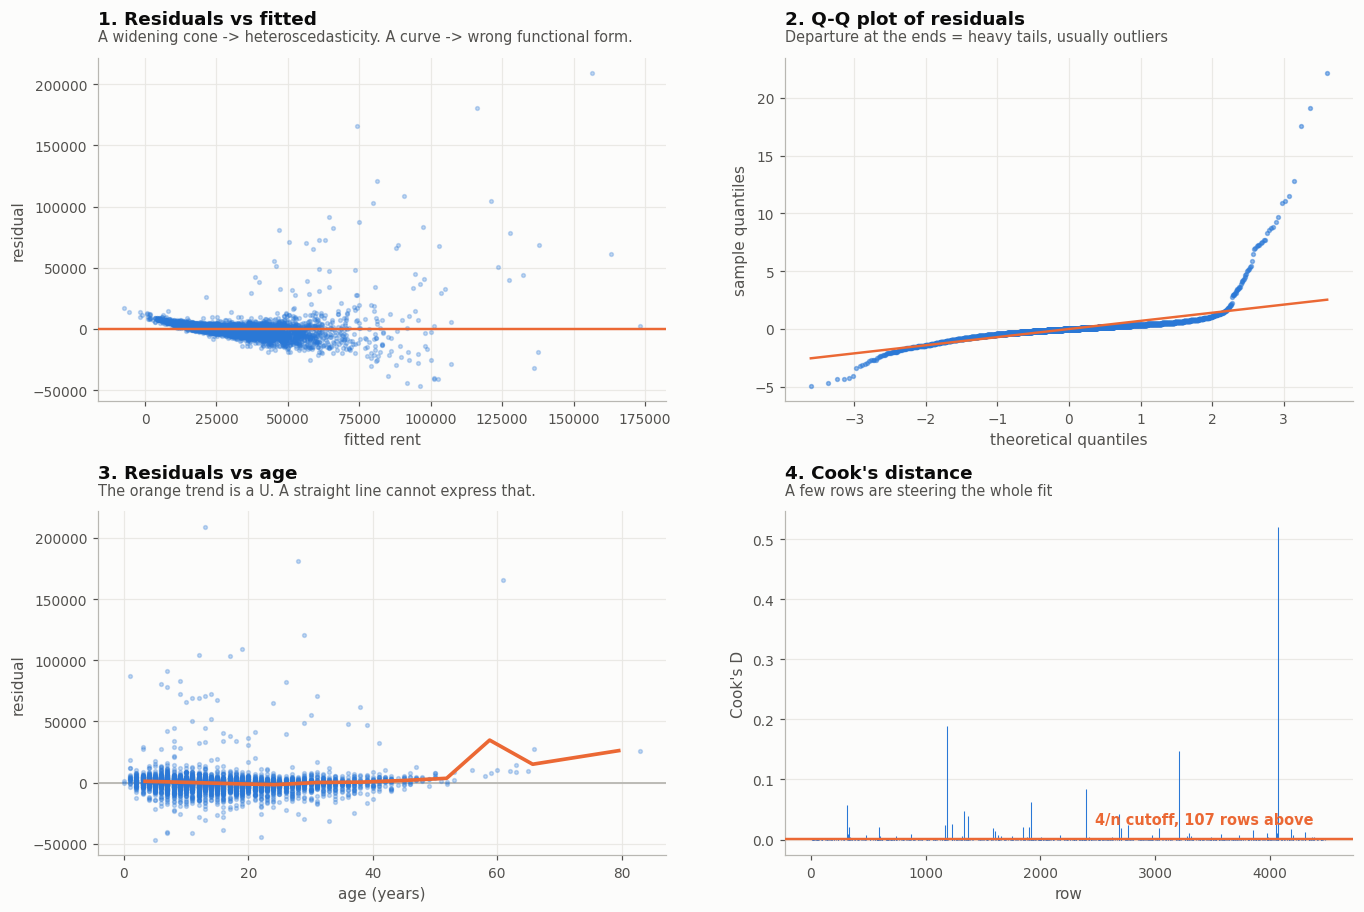

In [5]:
# ============================================================================
# 3.1  The four diagnostic plots
# ----------------------------------------------------------------------------
# In   : naive model, train
# Out  : residual, Q-Q, residual-vs-age and Cook's D plots
# Note : Every violation in this dataset is visible here before any test is
#        run.
# ============================================================================
resid = naive.resid
fitted_vals = naive.fittedvalues

fig, ax = plt.subplots(2, 2, figsize=(12.5, 8.4))

ax[0,0].scatter(fitted_vals, resid, s=6, alpha=.28, color=BLUE, zorder=3)
ax[0,0].axhline(0, color=ORANGE, lw=1.6, zorder=4)
style(ax[0,0], "1. Residuals vs fitted",
      "A widening cone -> heteroscedasticity. A curve -> wrong functional form.",
      "fitted rent", "residual", grid="both")

stats.probplot(resid / resid.std(), dist="norm", plot=ax[0,1])
ax[0,1].get_lines()[0].set(color=BLUE, marker="o", markersize=2.5, alpha=.5, ls="")
ax[0,1].get_lines()[1].set(color=ORANGE, lw=1.6)
style(ax[0,1], "2. Q-Q plot of residuals",
      "Departure at the ends = heavy tails, usually outliers",
      "theoretical quantiles", "sample quantiles", grid="both")

ax[1,0].scatter(train["age_years"], resid, s=6, alpha=.28, color=BLUE, zorder=3)
bins = pd.cut(train["age_years"], 12)
means = pd.Series(resid.values).groupby(bins.values, observed=True).mean()
centres = [i.mid for i in means.index]
ax[1,0].plot(centres, means.values, color=ORANGE, lw=2.4, zorder=5)
ax[1,0].axhline(0, color=MUTED, lw=1.2, zorder=2)
style(ax[1,0], "3. Residuals vs age",
      "The orange trend is a U. A straight line cannot express that.",
      "age (years)", "residual", grid="both")

infl = naive.get_influence()
cooks = infl.cooks_distance[0]
cutoff = 4 / len(cooks)
ax[1,1].vlines(range(len(cooks)), 0, cooks, color=BLUE, lw=.7, zorder=3)
ax[1,1].axhline(cutoff, color=ORANGE, lw=1.6, zorder=4)
ax[1,1].annotate(f"4/n cutoff, {(cooks > cutoff).sum()} rows above",
                 (len(cooks) * .55, cutoff), xytext=(0, 10),
                 textcoords="offset points", color=ORANGE, fontsize=9.5, weight="600")
style(ax[1,1], "4. Cook's distance",
      "A few rows are steering the whole fit", "row", "Cook's D")

plt.tight_layout(); plt.show()

All four failures are visible without a single test statistic. Now quantify
them, and say what each failure actually *costs*, because they do not all cost
the same thing.

In [6]:
# ============================================================================
# 3.2  Quantify the violations
# ----------------------------------------------------------------------------
# In   : naive model, train
# Out  : vif_table(), diagnose(), the check table
# Note : Each row states what the failure COSTS, because the failures are
#        not equally serious.
# ============================================================================
def vif_table(X):
    num = X.select_dtypes(include=[np.number]).astype(float)
    num = num.loc[:, num.std() > 0]
    M = np.column_stack([np.ones(len(num)), num.to_numpy()])
    return (pd.DataFrame({"feature": num.columns,
                          "vif": [variance_inflation_factor(M, i+1)
                                  for i in range(num.shape[1])]})
            .sort_values("vif", ascending=False, ignore_index=True))


def diagnose(res, X, label):
    exog = np.column_stack([np.ones(len(X)),
                            X.select_dtypes(include=[np.number]).to_numpy()])
    bp_lm, bp_p, _, _ = het_breuschpagan(res.resid, exog)
    reset = linear_reset(res, power=3, use_f=True)
    jb = stats.jarque_bera(res.resid)
    vt = vif_table(X)
    cooks = res.get_influence().cooks_distance[0]
    rows = [
        ("functional form (RESET)", reset.pvalue > .05, float(reset.fvalue),
         "MIS-SPECIFIED: coefficients are BIASED, not merely imprecise"),
        ("heteroscedasticity (BP)", bp_p > .05, float(bp_lm),
         "coefficients still unbiased; ALL standard errors and p-values invalid"),
        ("multicollinearity (VIF)", vt.vif.max() < 5, float(vt.vif.max()),
         "coefficients unstable, can flip sign; predictions unaffected"),
        ("residual normality (JB)", jb.pvalue > .05, float(jb.statistic),
         "usually a symptom of outliers or a missing transform"),
        ("influential points", (cooks > 4/len(cooks)).sum() == 0, float(cooks.max()),
         "a handful of rows are driving the coefficients"),
    ]
    return pd.DataFrame([{"model": label, "check": c,
                          "verdict": "PASS" if ok else "FAIL",
                          "statistic": round(s, 3), "if it fails": why}
                         for c, ok, s, why in rows])


X_naive = design(train, **naive_kw)
d_naive = diagnose(naive, X_naive, "naive")
print(d_naive.to_string(index=False))
print("\nworst VIFs:")
print(vif_table(X_naive).head(4).to_string(index=False))

model                   check verdict   statistic                                                           if it fails
naive functional form (RESET)    FAIL     475.084          MIS-SPECIFIED: coefficients are BIASED, not merely imprecise
naive heteroscedasticity (BP)    FAIL     420.646 coefficients still unbiased; ALL standard errors and p-values invalid
naive multicollinearity (VIF)    FAIL     355.489          coefficients unstable, can flip sign; predictions unaffected
naive residual normality (JB)    FAIL 3527499.644                  usually a symptom of outliers or a missing transform
naive      influential points    FAIL       0.520                        a handful of rows are driving the coefficients

worst VIFs:
     feature        vif
builtup_area 355.489125
 carpet_area 353.093023
    bedrooms   6.877098
   bathrooms   3.988375


Read the consequence column carefully, because the failures are **not equally
serious** and almost everyone treats them as if they were:

- **Functional form is the emergency.** A mis-specified model gives you biased
  coefficients. The number is simply wrong, and no amount of extra data fixes it.
- **Heteroscedasticity does not touch your coefficients.** It invalidates the
  *uncertainty* around them. The fix is robust standard errors, not panic.
- **Multicollinearity does not hurt predictions at all.** It destroys
  interpretation, which is the entire reason you picked a linear model.

Notice `carpet_area` and `builtup_area` at the top of the VIF table. They are
the same column wearing two hats.

                   mean     std     min     max  true
spec                                                 
both areas kept  0.5334  0.0845  0.3740  0.6992  0.62
twin dropped     0.6408  0.0060  0.6303  0.6484  0.62


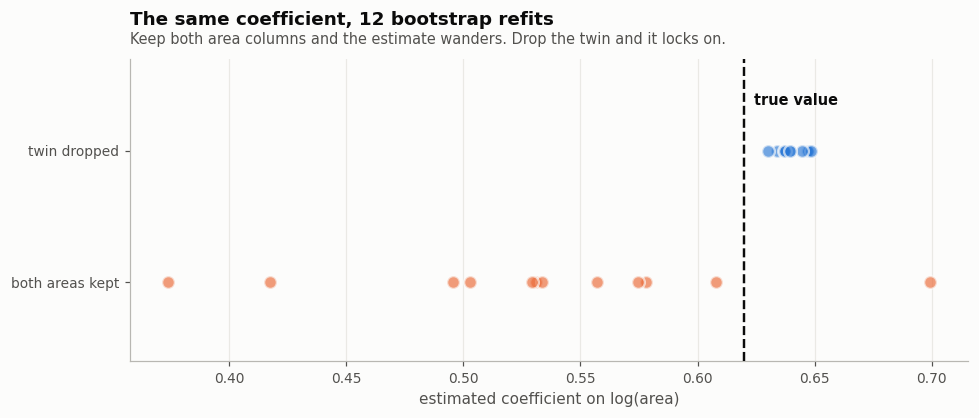

In [7]:
# ============================================================================
# 3.3  What collinearity does to a coefficient
# ----------------------------------------------------------------------------
# In   : train
# Out  : bootstrap spread of the log(area) coefficient
# Note : One fit hides this behind a single confident number; twelve refits
#        show the estimate wandering.
# ============================================================================
# What collinearity actually does: refit on bootstrap resamples and watch the
# SAME coefficient wander. One fit hides this behind a single confident number.
rows = []
for seed in range(12):
    boot = train.sample(len(train), replace=True, random_state=seed)
    for keep in (True, False):
        r, _ = fit_ols(boot, log_y=True, drop_twin=not keep)
        rows.append({"spec": "both areas kept" if keep else "twin dropped",
                     "beta": float(r.params["log_builtup_area"])})
spread = pd.DataFrame(rows).groupby("spec")["beta"].agg(["mean", "std", "min", "max"]).round(4)
spread["true"] = TRUE_BETAS["log_builtup_area"]
print(spread.to_string())

fig, ax = plt.subplots(figsize=(9, 3.9))
for i, (spec, g) in enumerate(pd.DataFrame(rows).groupby("spec")):
    ax.scatter(g["beta"], np.full(len(g), i), s=70, alpha=.65,
               color=[ORANGE, BLUE][i], zorder=3, edgecolor=SURFACE, linewidth=1.5)
ax.axvline(TRUE_BETAS["log_builtup_area"], color=INK, lw=1.6, ls="--", zorder=4)
ax.annotate("true value", (TRUE_BETAS["log_builtup_area"], 1.35), xytext=(6, 0),
            textcoords="offset points", fontsize=9.5, color=INK, weight="600")
ax.set_yticks([0, 1], sorted(pd.DataFrame(rows)["spec"].unique()))
ax.set_ylim(-.6, 1.7)
style(ax, "The same coefficient, 12 bootstrap refits",
      "Keep both area columns and the estimate wanders. Drop the twin and it locks on.",
      "estimated coefficient on log(area)", grid="x")
plt.tight_layout(); plt.show()

---
<a id="s4"></a>
## 4. Why R² cannot be the thing you optimise

R² **never falls** when you add a feature, not even a column of pure random
noise. So "our R² went up" is not evidence of anything at all.

We planted 8 junk columns for exactly this demonstration.

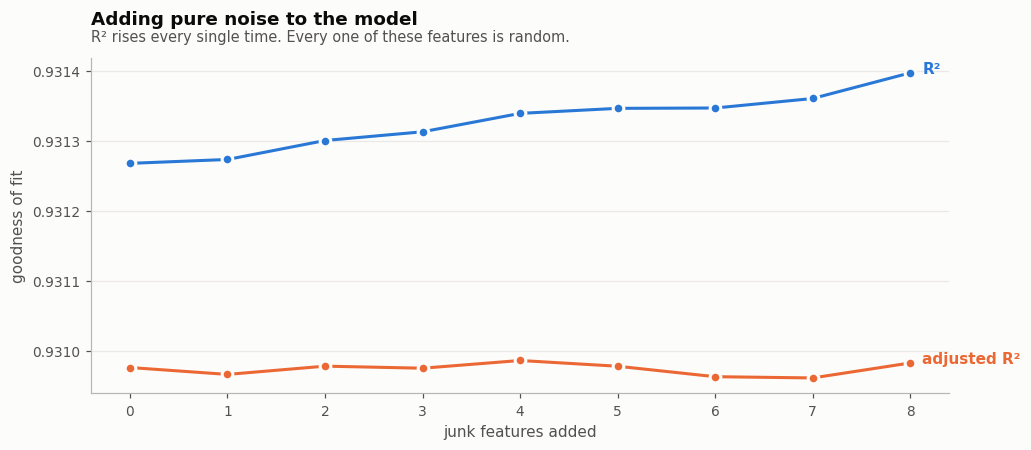

R2 never decreased: True
total R2 gained from 8 noise columns: +0.00013
adjusted R2 change:                   +0.00001


In [8]:
# ============================================================================
# 4.1  Why R-squared cannot be optimised
# ----------------------------------------------------------------------------
# In   : train
# Out  : R2 vs adjusted R2 as junk columns are added
# Note : All eight added features are pure noise. R2 rises every time.
# ============================================================================
Xj = design(train, junk=True)
junk_cols = [c for c in Xj.columns if c.startswith("junk_")]
base_cols = [c for c in Xj.columns if not c.startswith("junk_")]
y_log = np.log(train[TARGET])

rows, cols = [], list(base_cols)
for i, extra in enumerate([None] + junk_cols):
    if extra:
        cols.append(extra)
    r = sm.OLS(y_log, sm.add_constant(Xj[cols], has_constant="add")).fit()
    rows.append({"junk_added": i, "r2": r.rsquared, "adj_r2": r.rsquared_adj})
demo = pd.DataFrame(rows)
demo["r2_change"] = demo.r2.diff()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(demo.junk_added, demo.r2, color=BLUE, marker="o", zorder=4,
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=2)
ax.plot(demo.junk_added, demo.adj_r2, color=ORANGE, marker="o", zorder=4,
        markerfacecolor=ORANGE, markeredgecolor=SURFACE, markeredgewidth=2)
ax.annotate("R²", (demo.junk_added.iloc[-1], demo.r2.iloc[-1]), xytext=(8, 0),
            textcoords="offset points", color=BLUE, fontsize=10, weight="600")
ax.annotate("adjusted R²", (demo.junk_added.iloc[-1], demo.adj_r2.iloc[-1]),
            xytext=(8, 0), textcoords="offset points", color=ORANGE,
            fontsize=10, weight="600")
style(ax, "Adding pure noise to the model",
      "R² rises every single time. Every one of these features is random.",
      "junk features added", "goodness of fit")
plt.tight_layout(); plt.show()

print(f"R2 never decreased: {(demo.r2_change.dropna() >= -1e-12).all()}")
print(f"total R2 gained from 8 noise columns: {demo.r2.iloc[-1] - demo.r2.iloc[0]:+.5f}")
print(f"adjusted R2 change:                   {demo.adj_r2.iloc[-1] - demo.adj_r2.iloc[0]:+.5f}")

---
<a id="s5"></a>
## 5. Fixing exactly what the diagnostics named

No guesswork, no "let's try a different algorithm". Each fix answers one
specific failure:

| diagnostic said | fix |
|---|---|
| RESET: wrong functional form | model **log(rent)** on **log(area)** |
| VIF: two columns are one | drop `carpet_area` |
| residual-vs-age shows a U | add an explicit **quadratic age term** |
| Breusch-Pagan: non-constant variance | **HC3 robust** standard errors |

Still a linear model. Same data. Same family.

In [9]:
# ============================================================================
# 5.1  Fix exactly what the diagnostics named
# ----------------------------------------------------------------------------
# In   : train, test
# Out  : specified OLS, the accuracy table
# Note : Log target, log area, collinear twin dropped, explicit age curve,
#        HC3 robust errors. Still the same model family.
# ============================================================================
spec_kw = dict(log_area=True, drop_twin=True, age_curve=True)
spec, spec_cols = fit_ols(train, log_y=True, cov="HC3", **spec_kw)

def report(y_true, y_pred, k, label):
    y_true = np.asarray(y_true, float)
    err = y_true - y_pred
    ss = 1 - (err**2).sum() / ((y_true - y_true.mean())**2).sum()
    return {"model": label, "r2": round(ss, 4),
            "mae": round(np.abs(err).mean(), 1),
            "median_ape": round(float(np.median(np.abs(err / y_true))), 4),
            "n_features": k}

res_rows = [
    report(test[TARGET], predict_ols(naive, naive_cols, test, **naive_kw),
           len(naive_cols), "naive_ols"),
    report(test[TARGET], predict_ols(spec, spec_cols, test, log_y=True, **spec_kw),
           len(spec_cols), "specified_ols"),
]
print(pd.DataFrame(res_rows).to_string(index=False))
print("\ndiagnostics after the fixes:")
print(diagnose(spec, design(train, **spec_kw), "specified").to_string(index=False))

        model     r2    mae  median_ape  n_features
    naive_ols 0.7749 3973.4      0.0790          27
specified_ols 0.7869 2674.3      0.0412          19

diagnostics after the fixes:
    model                   check verdict  statistic                                                           if it fails
specified functional form (RESET)    FAIL    102.466          MIS-SPECIFIED: coefficients are BIASED, not merely imprecise
specified heteroscedasticity (BP)    FAIL    323.354 coefficients still unbiased; ALL standard errors and p-values invalid
specified multicollinearity (VIF)    FAIL      6.620          coefficients unstable, can flip sign; predictions unaffected
specified residual normality (JB)    FAIL 135615.671                  usually a symptom of outliers or a missing transform
specified      influential points    FAIL      0.146                        a handful of rows are driving the coefficients


**Error nearly halved. R² moved by about one point.**

That is the headline: the metric everyone watches barely twitched while the
thing that matters, how wrong the predictions are, improved enormously.

Now the part most tutorials would quietly skip. **The diagnostics are still not
all green,** and that is correct:

- **Heteroscedasticity still FAILS, deliberately.** The remedy was never to
  transform it away. It is HC3 robust standard errors, which this model uses.
  A failed test with the right remedy applied is a solved problem, not an
  outstanding one.
- **RESET still flags.** With thousands of rows these tests detect *trivial*
  departures. Watch the statistic fall by ~75%, not the pass/fail flip. Effect
  size, not significance.

A tutorial that shows all-green after the fixes is either using a tiny sample or
not telling you everything.

---
<a id="s6"></a>
## 6. The challenger

Gradient boosting on the same rows and the same raw columns: no log transform,
no collinearity surgery, no age curve. That is precisely why people reach for
it: it finds the shape by itself.

In [10]:
# ============================================================================
# 6.1  The gradient boosting challenger
# ----------------------------------------------------------------------------
# In   : train, test
# Out  : gbm, gbm_pred, updated accuracy table
# Note : Same rows, raw columns, none of the specification work. That is why
#        people reach for it.
# ============================================================================
def gbm_design(df):
    return design(df, log_area=False, drop_twin=False, age_curve=False)

Xg = gbm_design(train)
gbm = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=.06, max_leaf_nodes=31, min_samples_leaf=25,
    l2_regularization=1.0, early_stopping=True, validation_fraction=.15,
    random_state=SEED).fit(Xg, np.log(train[TARGET]))

gbm_pred = np.exp(gbm.predict(gbm_design(test).reindex(columns=Xg.columns, fill_value=0)))
res_rows.append(report(test[TARGET], gbm_pred, Xg.shape[1], "gbm"))
print(pd.DataFrame(res_rows).to_string(index=False))

        model     r2    mae  median_ape  n_features
    naive_ols 0.7749 3973.4      0.0790          27
specified_ols 0.7869 2674.3      0.0412          19
          gbm 0.7746 3014.5      0.0495          19


The GBM beats the naive model comfortably, and **loses to the specified linear
model**, while giving up every coefficient in the process.

Before drawing a general conclusion from that, see section 9: this market's true
form really *is* log-linear plus a quadratic, which is exactly the situation
where a correctly specified parametric model should win. The transferable point
is narrower and more useful: *fix the specification before you change families,
because you may be comparing against a model that was never allowed to compete.*

But the GBM is not finished being useful.

---
<a id="s7"></a>
## 7. SHAP, and the identity that makes it trustworthy

Here is the reconciliation people miss. **For a linear model, the SHAP value of
a feature is exactly `coef × (x - mean(x))`.** SHAP is not a newer, better kind
of explanation. On a linear model it *is* the coefficient, spread across rows.

Verify that by hand, and you have earned the right to trust SHAP on the tree,
where there is no coefficient to check it against.

In [11]:
# ============================================================================
# 7.1  SHAP, and the identity that makes it trustworthy
# ----------------------------------------------------------------------------
# In   : specified OLS, gbm, test
# Out  : ols_attr, gbm_attr
# Note : For a linear model SHAP equals coef * (x - mean(x)). Verifying that
#        by hand earns the right to trust SHAP on the tree.
# ============================================================================
# shap is the one optional dependency. Kaggle ships it, Colab does not.
# Install it when missing so "Run all" works everywhere, and carry on without
# it when there is no internet to install from.
try:
    import shap
except ModuleNotFoundError:
    import subprocess, sys
    print("shap not found, installing it (about 20s, needed on Colab only)...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=False)
    try:
        import shap
    except ModuleNotFoundError:
        shap = None
        print("shap could not be installed, so the library cross-check and the")
        print("tree attributions are skipped. Every other cell still runs.")

Xs = design(test, **spec_kw).reindex(columns=spec_cols, fill_value=0.0)
manual = pd.DataFrame({c: spec.params[c] * (Xs[c] - Xs[c].mean()) for c in spec_cols})
ols_attr = manual.abs().mean().sort_values(ascending=False)

if shap is not None:
    lib = shap.LinearExplainer(
        (spec.params[spec_cols].values, float(spec.params["const"])), Xs.values)
    lib_attr = pd.Series(np.abs(lib.shap_values(Xs.values)).mean(0), index=spec_cols)

    check = pd.DataFrame({"by hand": ols_attr, "shap library": lib_attr}).head(6).round(6)
    print(check.to_string())
    print(f"\nmax disagreement: {float((ols_attr - lib_attr).abs().max()):.3e}  <- same thing")

    Xg_test = gbm_design(test).reindex(columns=Xg.columns, fill_value=0)
    gbm_attr = pd.Series(
        np.abs(shap.TreeExplainer(gbm).shap_values(Xg_test.sample(800, random_state=SEED))).mean(0),
        index=Xg.columns).sort_values(ascending=False)
    print("\nGBM top attributions:")
    print(gbm_attr.head(6).round(4).to_string())
else:
    gbm_attr = None
    print("by-hand OLS attributions (the identity below still holds, it just is")
    print("not cross-checked against the library here):")
    print(ols_attr.head(6).round(6).to_string())

                 by hand  shap library
age_centred_sq  0.023123      0.022061
age_years       0.039649      0.039489
bathrooms       0.027740      0.028349
bedrooms        0.046211      0.042862
crime_index     0.050243      0.050568
floor           0.021124      0.021160

max disagreement: 6.093e-03  <- same thing



GBM top attributions:
builtup_area       0.1883
metro_km           0.0931
carpet_area        0.0508
crime_index        0.0490
furnishing_full    0.0447
bedrooms           0.0353


### An unplanned lesson: collinearity corrupts *tree* attributions too

Look at where the GBM puts the size signal. It was handed both `builtup_area`
and `carpet_area`, the same information twice, so it **divides** the credit
between them, and neither column looks as important as size actually is.

The specified OLS, given one combined `log_builtup_area` term, shows size as the
dominant driver it truly is.

Same data. Opposite impression of what matters. This is usually taught as a
regression-only problem; it is not.

In [12]:
# ============================================================================
# 7.2  Collinearity splits tree attributions too
# ----------------------------------------------------------------------------
# In   : gbm_attr, ols_attr
# Out  : the split-credit comparison
# Note : Given the same information twice, the GBM divides the size signal
#        and understates the strongest driver in the data.
# ============================================================================
if gbm_attr is None:
    print("shap is unavailable, so the split-credit comparison cannot be shown.")
else:
    twins = gbm_attr[gbm_attr.index.isin(["builtup_area", "carpet_area"])]
    print(f"GBM, size split across the twins : {dict(twins.round(4))}")
    print(f"GBM, combined                    : {twins.sum():.4f}")
    print(f"OLS, single log(area) term       : {ols_attr['log_builtup_area']:.4f}")
    print(f"\nGBM's top-ranked single feature  : {gbm_attr.index[0]}")
    print(f"OLS's top-ranked single feature  : {ols_attr.index[0]}")

GBM, size split across the twins : {'builtup_area': 0.1883, 'carpet_area': 0.0508}
GBM, combined                    : 0.2391
OLS, single log(area) term       : 0.2207

GBM's top-ranked single feature  : builtup_area
OLS's top-ranked single feature  : log_builtup_area


### Using the tree as a detective

Now put the GBM to its best use. Its attributions say `metro_km` matters more
than the linear model's coefficient implies. Check whether the metro effect
differs **by locality**, a question the main-effects OLS cannot answer, because
we never told it such a thing was possible.

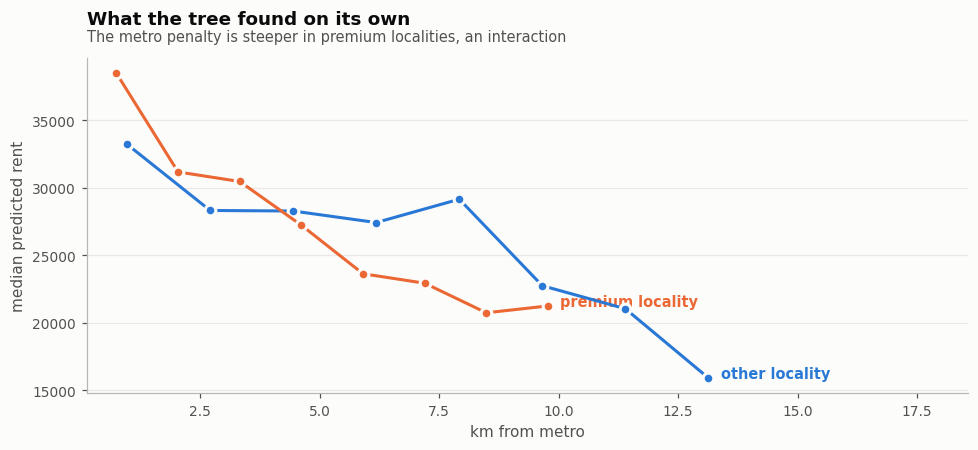

other locality       log-rent slope per km: -0.0456
premium locality     log-rent slope per km: -0.0680

the tree discovered an interaction nobody specified.


In [13]:
# ============================================================================
# 7.3  Use the tree as a detective
# ----------------------------------------------------------------------------
# In   : gbm predictions, test
# Out  : metro slope by locality, the interaction chart
# Note : The tree found an interaction nobody specified.
# ============================================================================
probe = test.copy()
probe["gbm_pred"] = gbm_pred
probe["premium"] = probe["locality"].isin(PREMIUM)

slopes = {}
for is_prem, g in probe.groupby("premium"):
    s = np.polyfit(g["metro_km"], np.log(g["gbm_pred"]), 1)[0]
    slopes["premium locality" if is_prem else "other locality"] = s

fig, ax = plt.subplots(figsize=(9, 4.2))
for (is_prem, g), colour in zip(probe.groupby("premium"), [BLUE, ORANGE]):
    lab = "premium locality" if is_prem else "other locality"
    binned = g.groupby(pd.cut(g["metro_km"], 8), observed=True)["gbm_pred"].median()
    ax.plot([i.mid for i in binned.index], binned.values, color=colour,
            marker="o", zorder=4, markerfacecolor=colour,
            markeredgecolor=SURFACE, markeredgewidth=2)
    ax.annotate(lab, ([i.mid for i in binned.index][-1], binned.values[-1]),
                xytext=(8, 0), textcoords="offset points", color=colour,
                fontsize=9.5, weight="600")
ax.set_xlim(right=ax.get_xlim()[1] * 1.35)
style(ax, "What the tree found on its own",
      "The metro penalty is steeper in premium localities, an interaction",
      "km from metro", "median predicted rent")
plt.tight_layout(); plt.show()

for k, v in slopes.items():
    print(f"{k:20s} log-rent slope per km: {v:+.4f}")
print("\nthe tree discovered an interaction nobody specified.")

---
<a id="s8"></a>
## 8. Telling the linear model what the tree found

A linear model represents interactions perfectly well. It just has to be
**told** they exist. The real difference between the two families is who has to
supply the structure, not how powerful they are.

          model     r2    mae  median_ape  n_features
interaction_ols 0.7850 2562.4      0.0376          20
  specified_ols 0.7869 2674.3      0.0412          19
            gbm 0.7746 3014.5      0.0495          19
      naive_ols 0.7749 3973.4      0.0790          27


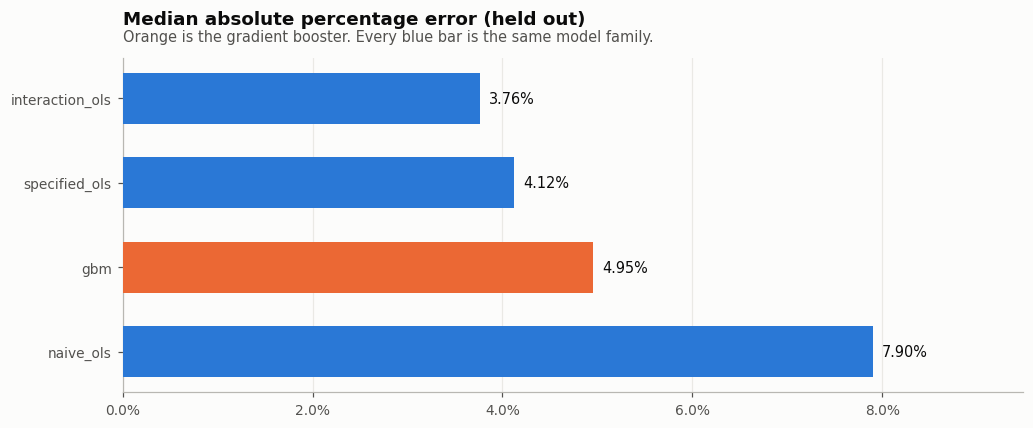

In [14]:
# ============================================================================
# 8.1  Tell the linear model what the tree found
# ----------------------------------------------------------------------------
# In   : train, test
# Out  : interaction OLS, the final accuracy table
# Note : A linear model handles interactions perfectly well once told they
#        exist.
# ============================================================================
int_kw = dict(log_area=True, drop_twin=True, age_curve=True, interaction=True)
inter, inter_cols = fit_ols(train, log_y=True, cov="HC3", **int_kw)
res_rows.append(report(test[TARGET],
                       predict_ols(inter, inter_cols, test, log_y=True, **int_kw),
                       len(inter_cols), "interaction_ols"))

final = pd.DataFrame(res_rows).sort_values("median_ape", ignore_index=True)
print(final.to_string(index=False))

fig, ax = plt.subplots(figsize=(9.5, 4))
order = final.sort_values("median_ape", ascending=False)
colours = [ORANGE if m == "gbm" else BLUE for m in order.model]
bars = ax.barh(range(len(order)), order.median_ape, color=colours, height=.6, zorder=3)
ax.set_yticks(range(len(order)), order.model)
for b, v in zip(bars, order.median_ape):
    ax.annotate(f"{v:.2%}", (v, b.get_y() + b.get_height()/2), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9.5, color=INK)
ax.set_xlim(0, order.median_ape.max() * 1.2)
ax.xaxis.set_major_formatter(PercentFormatter(1))
style(ax, "Median absolute percentage error (held out)",
      "Orange is the gradient booster. Every blue bar is the same model family.",
      grid="x")
plt.tight_layout(); plt.show()

### Now the question no real dataset can answer

Every model above produced predictions. But we know the **true coefficients**,
so we can ask which model recovered *reality*, not merely which one fit.

In [15]:
# ============================================================================
# 8.2  Score every model against the known truth
# ----------------------------------------------------------------------------
# In   : fitted models, TRUE_BETAS
# Out  : recovery table per coefficient
# Note : The question no real dataset can answer: which model recovered
#        reality, rather than which one fit best.
# ============================================================================
COEF_MAP = {"log_builtup_area": "log_builtup_area", "bedrooms": "bedrooms",
            "bathrooms": "bathrooms", "floor": "floor", "has_lift": "has_lift",
            "has_parking": "has_parking", "furnishing_semi": "furnished_semi",
            "furnishing_full": "furnished_full", "metro_km": "metro_km",
            "school_rating": "school_rating", "crime_index": "crime_index",
            "metro_km_x_premium": "metro_km_x_premium"}


def recovery(res, label):
    rows = []
    for col, key in COEF_MAP.items():
        if col not in res.params.index:
            continue
        true, est = TRUE_BETAS[key], float(res.params[col])
        ci = res.conf_int().loc[col]
        rows.append({"model": label, "term": col, "true": true,
                     "estimated": round(est, 4),
                     "pct_error": round(100*(est-true)/abs(true), 1),
                     "ci_covers_truth": bool(ci[0] <= true <= ci[1])})
    return pd.DataFrame(rows)


rec = pd.concat([recovery(spec, "specified_ols"),
                 recovery(inter, "interaction_ols")], ignore_index=True)
print(rec[rec.model == "interaction_ols"].to_string(index=False))
print()
for m, g in rec.groupby("model"):
    print(f"{m:18s} mean |error| {g.pct_error.abs().mean():5.1f}%   "
          f"CI covered truth {g.ci_covers_truth.mean():.0%}")
print("\ngbm                mean |error|    --     no coefficients exist")

          model               term   true  estimated  pct_error  ci_covers_truth
interaction_ols   log_builtup_area  0.620     0.6394        3.1            False
interaction_ols           bedrooms  0.045     0.0536       19.2            False
interaction_ols          bathrooms  0.035     0.0389       11.2             True
interaction_ols              floor  0.004     0.0040        0.4             True
interaction_ols           has_lift  0.055     0.0557        1.2             True
interaction_ols        has_parking  0.070     0.0689       -1.5             True
interaction_ols    furnishing_semi  0.090     0.0886       -1.5             True
interaction_ols    furnishing_full  0.185     0.1904        2.9             True
interaction_ols           metro_km -0.048    -0.0488       -1.6             True
interaction_ols      school_rating  0.028     0.0282        0.6             True
interaction_ols        crime_index -0.031    -0.0318       -2.6             True
interaction_ols metro_km_x_p



interaction_ols    mean |error|   3.9%   CI covered truth 83%
specified_ols      mean |error|   7.9%   CI covered truth 82%

gbm                mean |error|    --     no coefficients exist


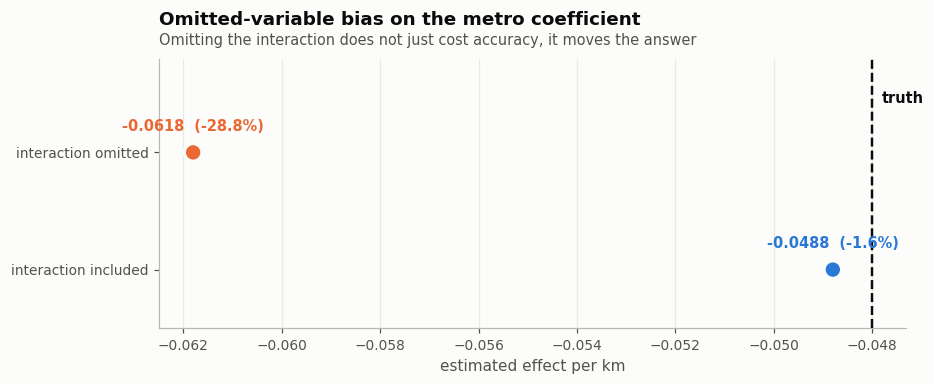

omitted : -0.0618  (-28.8% from truth)
included: -0.0488  (-1.6% from truth)

On real data you would never have known the first number was wrong.


In [16]:
# ============================================================================
# 8.3  Omitted-variable bias, made visible
# ----------------------------------------------------------------------------
# In   : recovery table
# Out  : the metro coefficient with and without the interaction
# Note : Leaving the interaction out moves the answer, it does not merely
#        cost accuracy.
# ============================================================================
# Omitted-variable bias, made visible. Leaving the interaction out does not
# merely cost accuracy -- it BIASES the metro main effect.
a = rec[(rec.model=="specified_ols") & (rec.term=="metro_km")].iloc[0]
b = rec[(rec.model=="interaction_ols") & (rec.term=="metro_km")].iloc[0]

fig, ax = plt.subplots(figsize=(8.6, 3.6))
ax.scatter([a.estimated, b.estimated], [1, 0], s=130, color=[ORANGE, BLUE],
           zorder=4, edgecolor=SURFACE, linewidth=2)
ax.axvline(TRUE_BETAS["metro_km"], color=INK, lw=1.6, ls="--", zorder=3)
ax.annotate("truth", (TRUE_BETAS["metro_km"], 1.42), xytext=(6, 0),
            textcoords="offset points", fontsize=9.5, color=INK, weight="600")
for y_, r_, c_ in [(1, a, ORANGE), (0, b, BLUE)]:
    ax.annotate(f"{r_.estimated:+.4f}  ({r_.pct_error:+.1f}%)",
                (r_.estimated, y_), xytext=(0, 14), textcoords="offset points",
                ha="center", fontsize=9.5, color=c_, weight="600")
ax.set_yticks([0, 1], ["interaction included", "interaction omitted"])
ax.set_ylim(-.5, 1.8)
style(ax, "Omitted-variable bias on the metro coefficient",
      "Omitting the interaction does not just cost accuracy, it moves the answer",
      "estimated effect per km", grid="x")
plt.tight_layout(); plt.show()

print(f"omitted : {a.estimated:+.4f}  ({a.pct_error:+.1f}% from truth)")
print(f"included: {b.estimated:+.4f}  ({b.pct_error:+.1f}% from truth)")
print("\nOn real data you would never have known the first number was wrong.")

---
<a id="s9"></a>
## 9. What to take away

**The findings, in order of how much they should change your practice**

1. **Specification beat the algorithm.** Naive → specified OLS roughly halved
   the error. Switching to gradient boosting did not. The linear model was never
   the weak part; the unexamined assumptions were.
2. **R² was the wrong dial.** It moved about one point while error fell by half,
   and it *rises when you add pure noise*, so it can never justify a feature.
   Use held-out MAE or median APE, and adjusted R² if you want an in-sample
   number.
3. **Diagnose before you switch families.** Every fix here came from a specific
   failed check, not from taste.
4. **The failures are not equally serious.** Wrong functional form biases your
   coefficients, which is an emergency. Heteroscedasticity leaves them unbiased
   and only invalidates the standard errors, which is a robust-errors problem.
   Collinearity does not touch predictions at all and only wrecks
   interpretation.
5. **The tree was the better detective, not the better model.** It found the
   interaction unaided. Once the linear model was told, it won again *and* could
   still quote the effect with a confidence interval.
6. **Collinearity corrupts SHAP too.** Given the same information twice, the GBM
   split the size signal between two columns and understated the most important
   driver in the dataset. This is not a regression-only failure mode.
7. **Omitting the interaction biased the metro coefficient by ~29%.** That is
   bias, not noise. Visible here only because we had an answer key.

**The honest limitation.** This market is generated, and its true form is
log-linear plus a quadratic plus one interaction. That is *why* the correctly
specified OLS wins. **Do not generalise this to "linear beats trees."** On real
housing data, with spatial non-linearity, many interactions and messy
categoricals, gradient boosting usually does win on accuracy, often by a lot.

What generalises is the **workflow**: diagnose first, read each diagnostic as a
specification instruction rather than a verdict, use the flexible model to
*discover* structure, then decide deliberately whether you want that structure
as an explicit, quotable term. That sequence is right no matter which model ends
up on top.

**When to choose which**

| you need | choose |
|---|---|
| an effect size with a confidence interval | the specified linear model |
| to defend the model to a regulator | the specified linear model |
| to extrapolate beyond the training range | the specified linear model |
| maximum accuracy on messy, interaction-heavy data | the tree |
| to *discover* structure you did not anticipate | the tree, then feed it back |